In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import matplotlib.pyplot as plt
from geodesic_toolbox import *
from functools import partial
from sklearn.datasets import make_swiss_roll
from utils import *
from scipy.special import factorial
from einops import rearrange
import pandas as pd
import seaborn as sns

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


# Data setup

In [2]:
device = "cpu"

In [ ]:


def get_x_plt(resolution: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[2], bounds[3], resolution)
    xx, yy = np.meshgrid(x, y)
    X_plt = np.stack([xx.flatten(), yy.flatten()], axis=1)
    return torch.from_numpy(X_plt).float().to(device)


In [4]:
def sample_uniform(n_samples: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.random.uniform(bounds[0], bounds[1], n_samples)
    y = np.random.uniform(bounds[2], bounds[3], n_samples)
    samples = np.stack([x, y], axis=1)
    return torch.from_numpy(samples).float().to(device)

In [5]:
class RoundOmega(torch.nn.Module):
    def __init__(self, cometric: CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = z.clone()
        omega[:, 0] = -self.freq * z[:, 1]
        omega[:, 1] = self.freq * z[:, 0]
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega

class ConstantOmega(torch.nn.Module):
    def __init__(self, cometric: CoMetric, beta: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.beta = beta

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = torch.zeros_like(z)
        omega[:, 0] = self.beta
        return omega



In [6]:
N = 5000
m = 2
X = sample_uniform(N, bounds=(-2, 2, -2, 2))
X = X.to(torch.float).to(device)
bounds = get_bounds(X, margin=0.01)


In [7]:
# base_cometric = CentroidsCometric(X, IdentityCoMetric()(X),kappa=1.0).to(device)
base_cometric = IdentityCoMetric().to(device)

omega_true = RoundOmega(base_cometric, freq=1.0)
omega_true = ConstantOmega(base_cometric)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.5
)

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 33632.77batch/s]


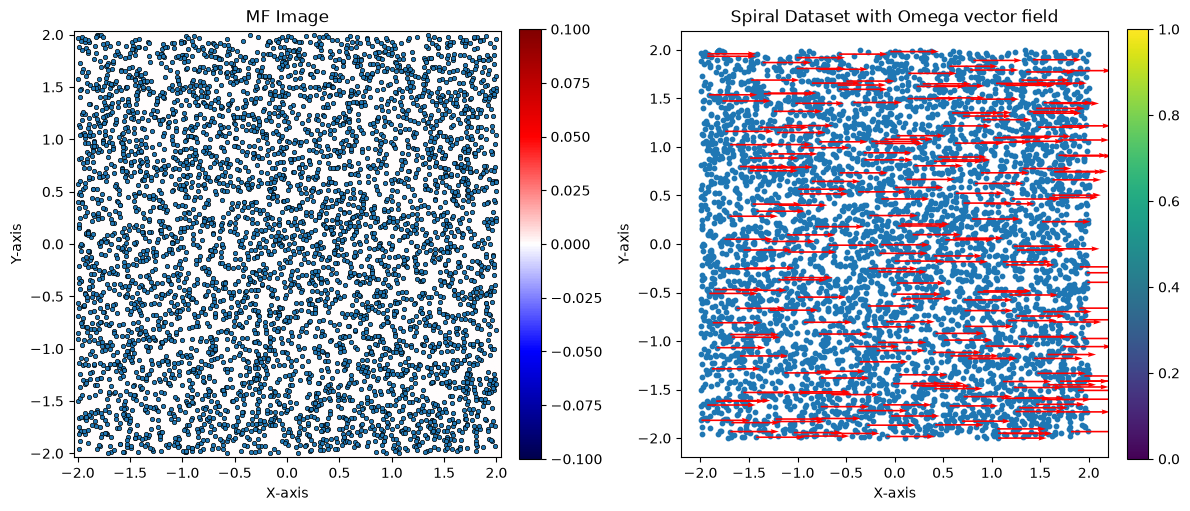

In [ ]:
mf = get_mf_image(base_cometric, X, bounds)
omega_X = randers_metric.omega(X) * randers_metric.beta

fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_xlim(bounds[0], bounds[1])
axes[0].set_ylim(bounds[2], bounds[3])
axes[0].set_title("Density of the Dataset")
axes[1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), s=10)
skip = 20  # Adjust this value to change the density of the quiver plot
axes[1].quiver(X[::skip, 0].cpu(), X[::skip, 1].cpu(), omega_X[::skip, 0].cpu(), omega_X[::skip, 1].cpu(), color='red', scale=1, angles='xy',scale_units='xy')
axes[1].set_title("Dataset with Omega vector field")
for ax in axes:
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_aspect('equal', adjustable='box')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.tight_layout()
plt.show()

# Construct operators

In [9]:
edges = get_knn_graph(X,n_neighbors=10,device=device)
print(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric)

Found 50000 edges in the KNN graph.


100%|██████████| 500/500 [00:35<00:00, 14.20it/s]


In [10]:
# epsilon = compute_epsilon_rate(N, m) 
epsilon = compute_epsilon_empirical(edges, dst_edges, N) * 0.5
print(f"For {N = }, {m = }, epsilon = {epsilon}")
W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon,N,m)
# W, mu_0, mu_1 = laplacian_kernel(edges, dst_edges, epsilon,N,m)
c_km = - mu_1 / mu_0 * (m+1)/m
L_theta_s, L_theta_a = construct_operators(W, epsilon,theta=1)

For N = 5000, m = 2, epsilon = 0.019343821331858635


# Construct test functions infos

In [11]:
f_values_m, Lf_values_m, f_grad_values_m = mexican_family(X, L_theta_a, scale_list=[0.1, 0.2, 0.3, 0.4, 0.5])
f_values_g, Lf_values_g, f_grad_values_g = gaussian_family(X, L_theta_a, sigma_list=[0.1, 0.2, 0.3, 0.4, 0.5])

f_values = torch.cat([f_values_m, f_values_g], dim=0)
Lf_values = torch.cat([Lf_values_m, Lf_values_g], dim=0)
f_grad_values = torch.cat([f_grad_values_m, f_grad_values_g], dim=0)

print(f"shapes : {f_values.shape}, {Lf_values.shape}, {f_grad_values.shape}")

# Check no problem with gradients
assert torch.all(torch.isfinite(f_grad_values)), "f_grad_values contains NaN or Inf"
assert torch.all(torch.isfinite(Lf_values)), "Lf_values contains NaN or Inf"

shapes : torch.Size([50000, 5000]), torch.Size([50000, 5000]), torch.Size([50000, 5000, 2])


# Verify operator correcteness

In [12]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X))
v_true_norm = v_true.norm(dim=1) 
b_true_hat = v_to_b(v_true, base_cometric.metric_tensor(X))
print(f"Max error between b_true and b_true_hat: {(b_true_hat - b_true).norm(dim=1).max()}")

Max error between b_true and b_true_hat: 0.0


Lf_values_constant should be zero
Lf_values_constant: mean = 9.94e-09, std = 2.79e-06, min = -1.14e-05, max = 1.14e-05


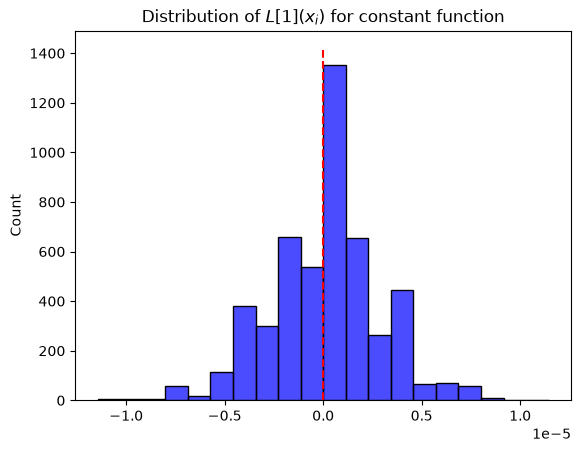

In [33]:
# One a constant function
f_values_constant = torch.ones((1, X.shape[0]), device=device)
Lf_values_constant = L_theta_a @ f_values_constant.T  # (N, 1)
Lf_values_constant = Lf_values_constant.T  # (1, N)
f_grad_values_constant = torch.zeros((1, X.shape[0], X.shape[1]), device=device)  # (1, N, D)

print(f"Lf_values_constant should be zero")
print(f"Lf_values_constant: mean = {Lf_values_constant.mean().item():.2e}, std = {Lf_values_constant.std().item():.2e}, min = {Lf_values_constant.min().item():.2e}, max = {Lf_values_constant.max().item():.2e}")
sns.histplot(Lf_values_constant.flatten().cpu().detach().numpy(), bins=20, color='blue', alpha=0.7)
plt.gca().set_title('Distribution of $L[1](x_i)$ for constant function')
plt.vlines(x=0, ymin=0, ymax=plt.gca().get_ylim()[1], colors='red', linestyles='dashed', label='y=0')
plt.show()

Delta_rhs_norm = $\lVert Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>\rVert$
Delta_rhs_norm: mean = 103.78, std = 114.28, min = 10.18, max = 745.68


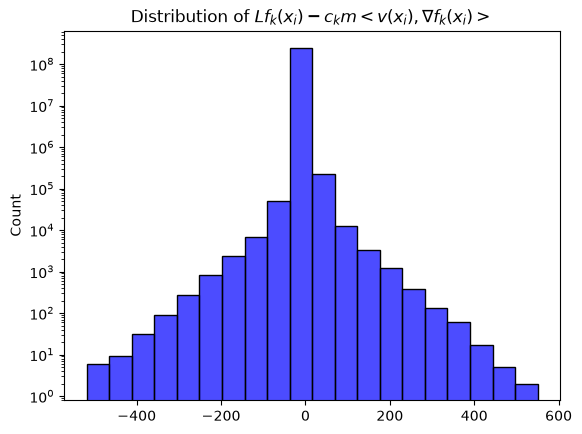

Ratio_rhs_mean should be 1
Ratio_rhs_mean: mean = -inf, std = nan, min = -inf, max = 1576.16


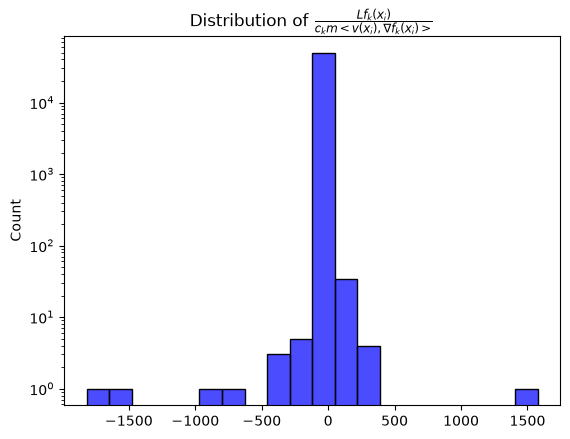

In [34]:
true_rhs = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values)

# Difference between true_rhs and Lf_values
delta_rhs = true_rhs - Lf_values
delta_rhs_norm = torch.norm(delta_rhs, dim=1)

print(r'Delta_rhs_norm = $\lVert Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>\rVert$')
print(f"Delta_rhs_norm: mean = {delta_rhs_norm.mean().item():.2f}, std = {delta_rhs_norm.std().item():.2f}, min = {delta_rhs_norm.min().item():.2f}, max = {delta_rhs_norm.max().item():.2f}")
sns.histplot(delta_rhs.flatten().cpu().detach().numpy(), bins=20, color='blue', alpha=0.7)
plt.gca().set_yscale('log')
plt.title(r'Distribution of $Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>$')
plt.show()

# Ratio between true_rhs and Lf_values
ratio_rhs = true_rhs / (Lf_values + 1e-8)  # Avoid division by zero
ratio_rhs_mean = ratio_rhs.mean(dim=1)
print(f"Ratio_rhs_mean should be 1")
print(f"Ratio_rhs_mean: mean = {ratio_rhs_mean.mean().item():.2f}, std = {ratio_rhs_mean.std().item():.2f}, min = {ratio_rhs_mean.min().item():.2f}, max = {ratio_rhs_mean.max().item():.2f}")
sns.histplot(ratio_rhs_mean.flatten().cpu().detach().numpy(), bins=20, color='blue', alpha=0.7)
plt.gca().set_yscale('log')
plt.title(r'Distribution of $\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>}$')
plt.show()


# Exact estimation of b

In [15]:
# Solve the problem
v_hat = solve_lstsq(f_grad_values, Lf_values, c_km)
b_hat = v_to_b(v_hat, base_cometric.metric_tensor(X))

In [16]:
print(f"Should be the same values: {b_hat.norm(dim=1).mean()=:.2f}, {b_true.norm(dim=1).mean()=:.2f}" )

Should be the same values: b_hat.norm(dim=1).mean()=0.60, b_true.norm(dim=1).mean()=0.50


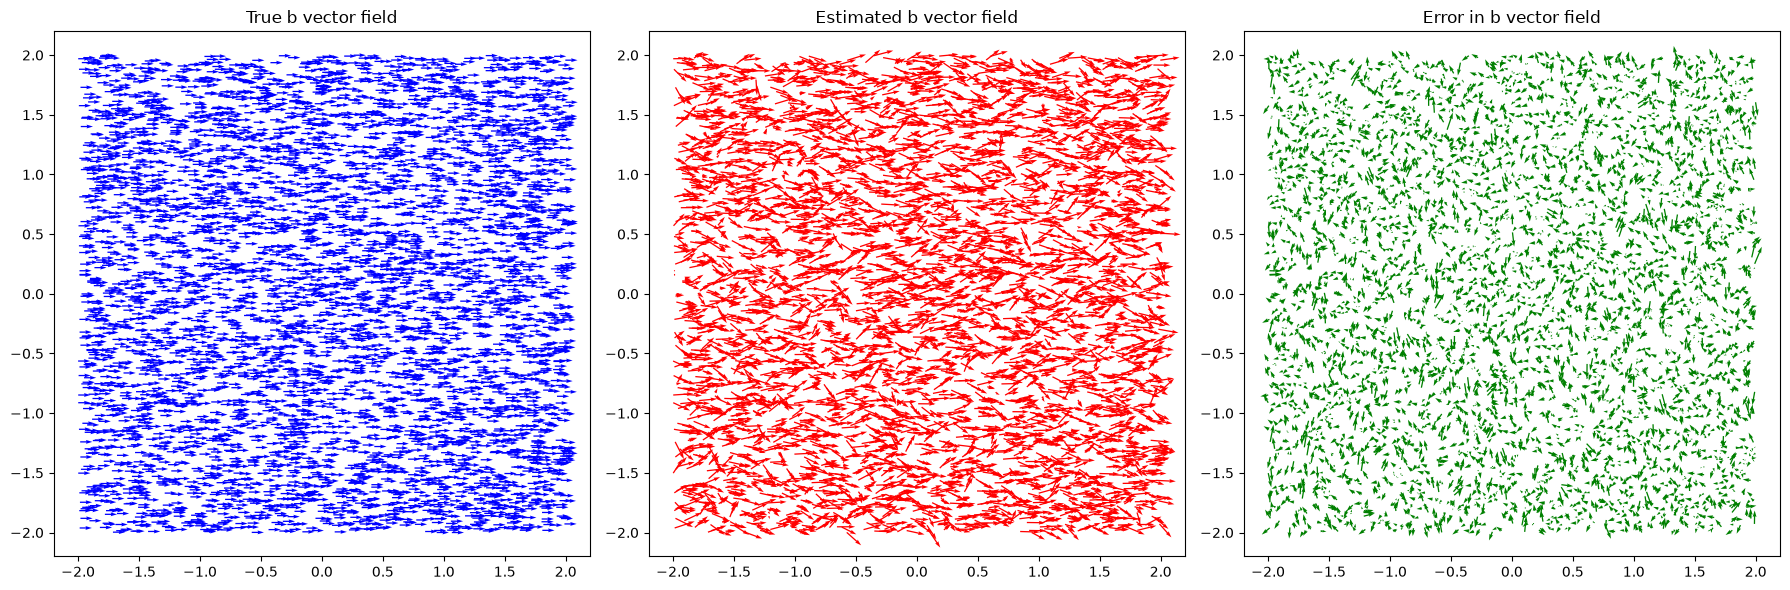

In [ ]:
plot_side_by_side(X, b_true, b_hat)

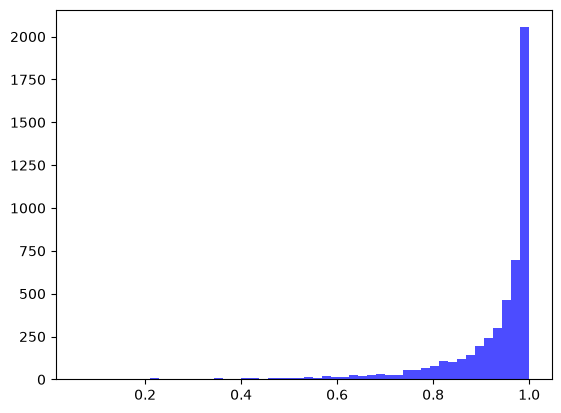

In [18]:
cosim = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cosine_similarity = cosim(b_true, b_hat)
cosine_similarity
plt.hist(cosine_similarity.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.show()

Alpha ratio should be 1
Alpha ratio: mean = 1.00, std = 0.47, min = 0.00, max = 3.35


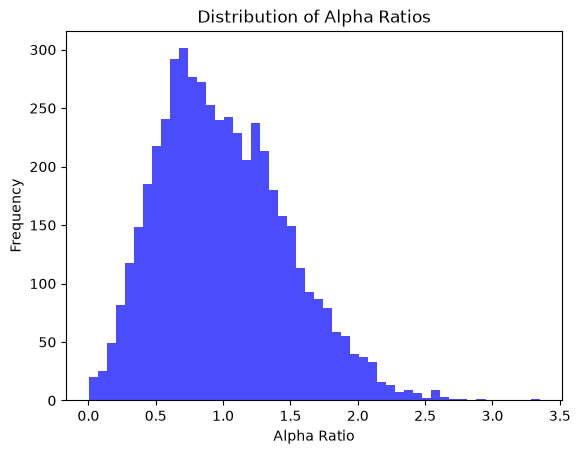

In [30]:
v_hat_deep_norm = v_hat.norm(dim=1)**2
alpha_ratio = torch.einsum("nd,nd->n", v_hat, v_true) / (v_true_norm + 1e-8)  # Avoid division by zero
print(f"Alpha ratio should be 1")
print(f"Alpha ratio: mean = {alpha_ratio.mean().item():.2f}, std = {alpha_ratio.std().item():.2f}, min = {alpha_ratio.min().item():.2f}, max = {alpha_ratio.max().item():.2f}")
plt.hist(alpha_ratio.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.xlabel('Alpha Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Alpha Ratios')
plt.show()

# Deep estimation of b

In [19]:
v_model = V_estimator(hidden_dims=[64, 64], dim=2).to(device)
omega_model = OmegaFromV(v_estimator=v_model, cometric=base_cometric).to(device)
randers_model = RandersMetrics(base_cometric=base_cometric, omega=omega_model, beta=1.0).to(device)

In [20]:
loss_list = learn_v(X, f_values, Lf_values, f_grad_values, c_km, v_model, device=device)

Loss: 2.1866e+00: 100%|██████████| 1000/1000 [00:02<00:00, 359.52it/s]


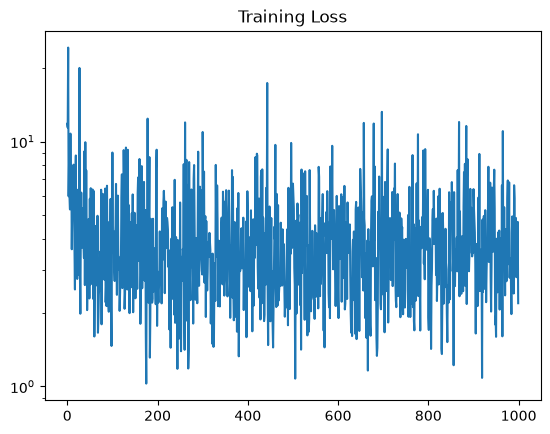

In [21]:
plt.plot(loss_list)
plt.title("Training Loss")
plt.yscale("log")

In [22]:
v_hat_deep = v_model(X).detach()
b_hat_deep = omega_model(X).detach()

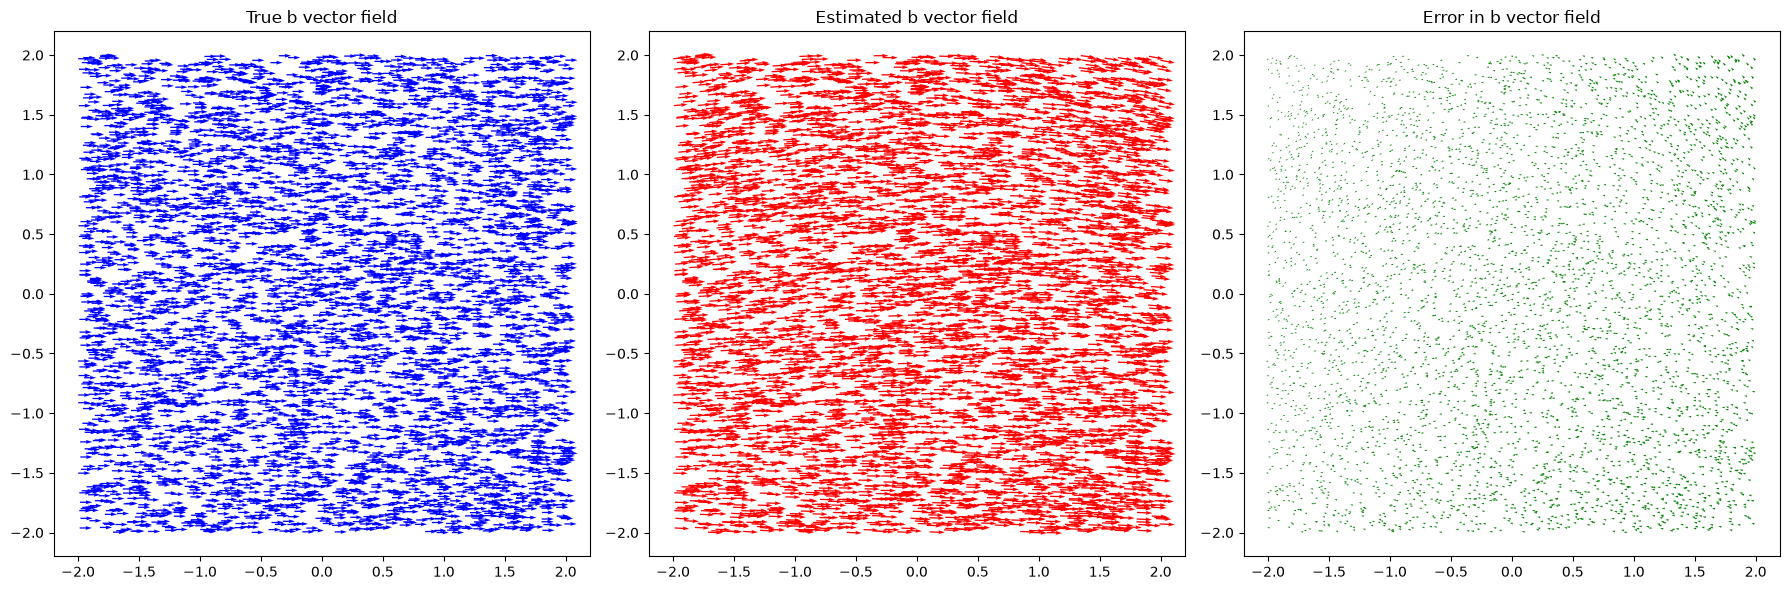

In [29]:
plot_side_by_side(X, b_true, b_hat_deep)

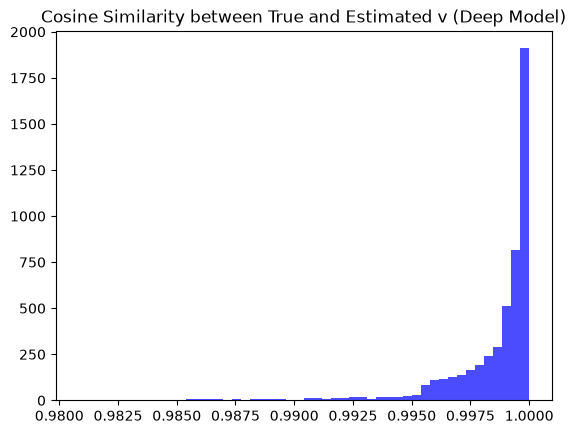

In [24]:
cosim = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cosine_similarity_deep = cosim(v_hat_deep, v_true)
plt.hist(cosine_similarity_deep.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.title("Cosine Similarity between True and Estimated v (Deep Model)")
plt.show()

Alpha ratio should be 1
Alpha ratio: mean = 0.96, std = 0.05, min = 0.81, max = 1.05


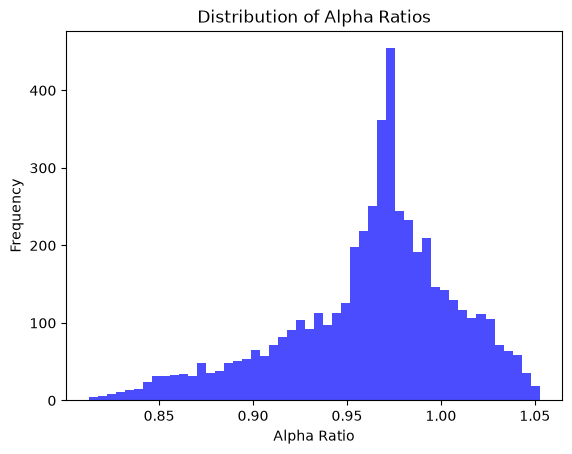

In [26]:
v_hat_deep_norm = v_hat_deep.norm(dim=1)**2
alpha_ratio = torch.einsum("nd,nd->n", v_hat_deep, v_true) / (v_true_norm + 1e-8)  # Avoid division by zero
print(f"Alpha ratio should be 1")
print(f"Alpha ratio: mean = {alpha_ratio.mean().item():.2f}, std = {alpha_ratio.std().item():.2f}, min = {alpha_ratio.min().item():.2f}, max = {alpha_ratio.max().item():.2f}")
plt.hist(alpha_ratio.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.xlabel('Alpha Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Alpha Ratios')
plt.show()